<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 105 amostras
Teste:  45 amostras


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

acc_train = accuracy_score(y_train, clf.predict(X_train))
acc_test = accuracy_score(y_test, clf.predict(X_test))

print(f"Acurácia no treino: {acc_train:.4f}")
print(f"Acurácia no teste:  {acc_test:.4f}")

Acurácia no treino: 1.0000
Acurácia no teste:  0.9333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

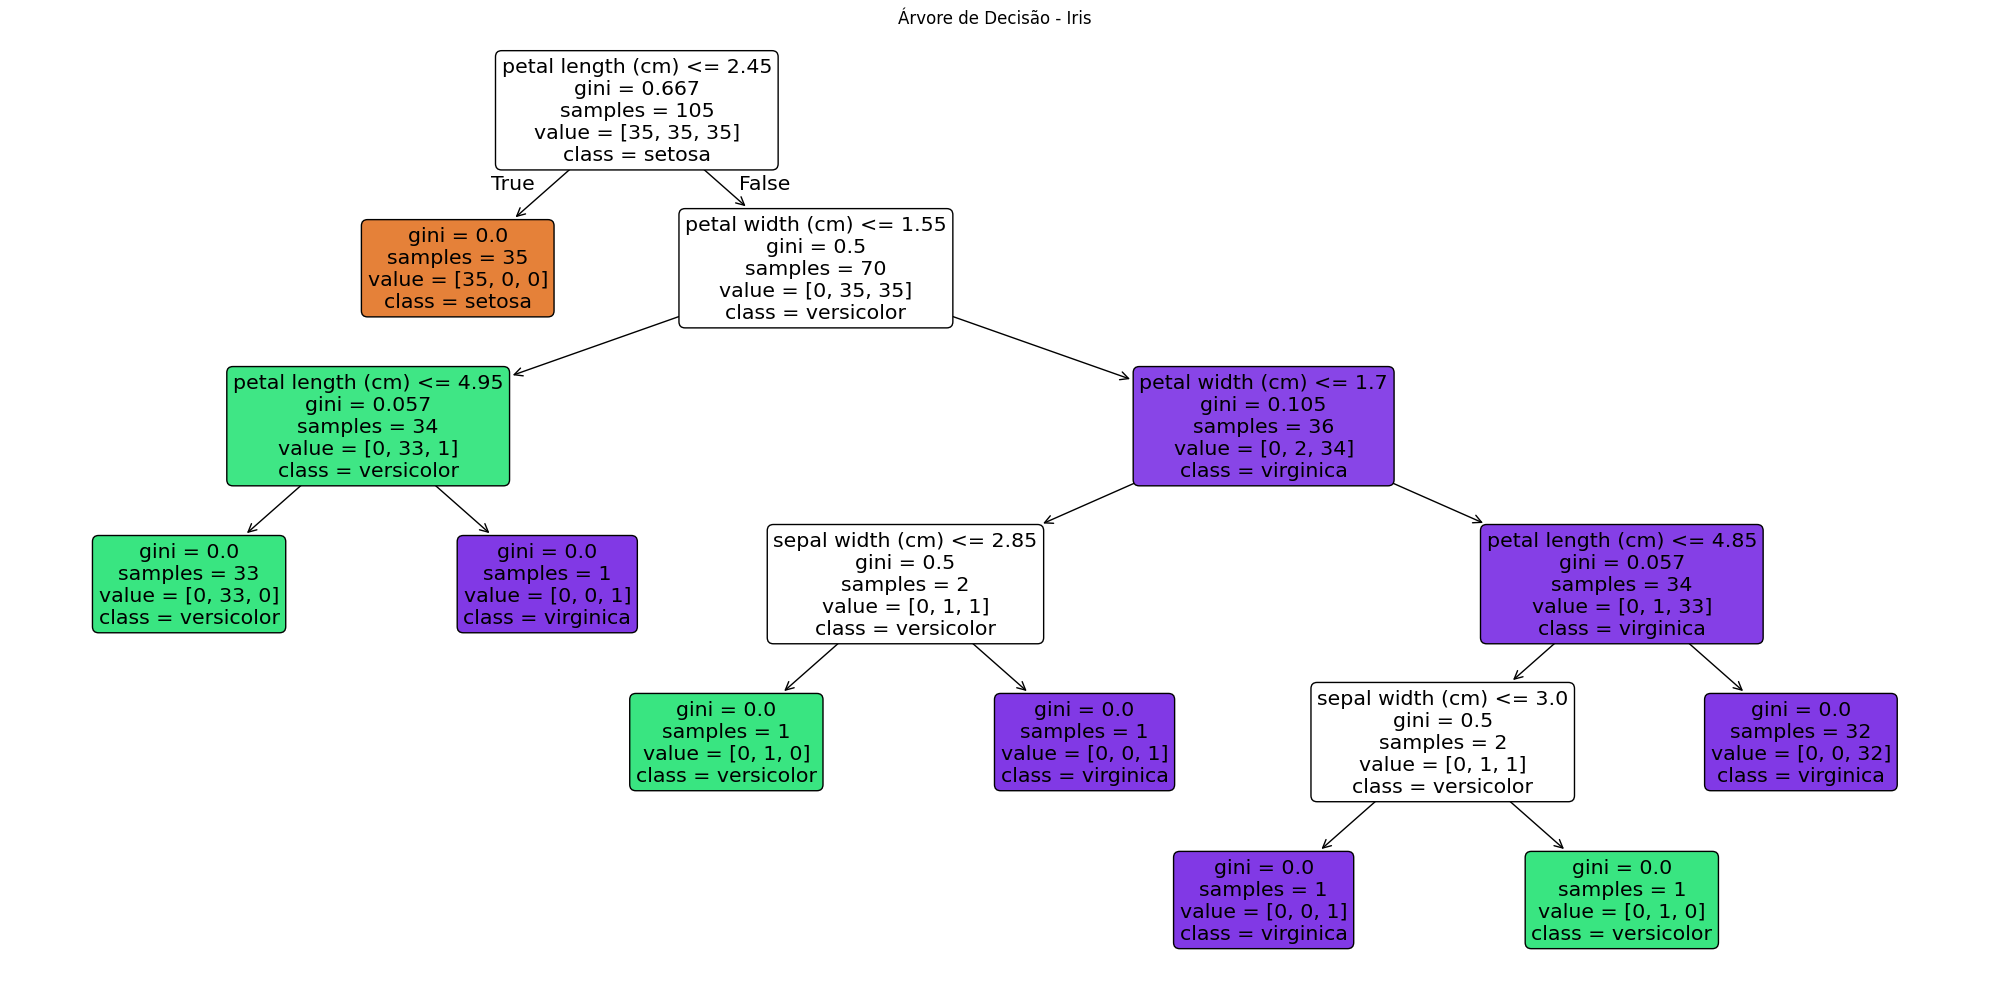

Atributo na raiz: petal length (cm)
Profundidade da árvore: 5


In [3]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True)
plt.title("Árvore de Decisão - Iris")
plt.tight_layout()
plt.show()

print(f"Atributo na raiz: {iris.feature_names[clf.tree_.feature[0]]}")
print(f"Profundidade da árvore: {clf.get_depth()}")

**Adicione seu texto de solução aqui**.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [4]:
import pandas as pd

depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, None]
results = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    results.append({
        "max_depth": str(d),
        "acurácia_treino": round(accuracy_score(y_train, tree.predict(X_train)), 4),
        "acurácia_teste": round(accuracy_score(y_test, tree.predict(X_test)), 4),
        "profundidade": tree.get_depth(),
        "num_folhas": tree.get_n_leaves()
    })

df_results = pd.DataFrame(results)
df_results

,max_depth,acurácia_treino,acurácia_teste,profundidade,num_folhas
0,1,0.6667,0.6667,1,2
1,2,0.9714,0.8889,2,3
2,3,0.9810,0.9778,3,5
3,4,0.9905,0.8889,4,7
4,5,1.0000,0.9333,5,8
5,6,1.0000,0.9333,5,8
6,7,1.0000,0.9333,5,8
7,8,1.0000,0.9333,5,8
8,9,1.0000,0.9333,5,8
9,None,1.0000,0.9333,5,8


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

**Em qual profundidade começa o overfitting?**
O overfitting começa a aparecer quando a acurácia de treino é significativamente maior que a de teste. Observando a tabela, isso geralmente começa por volta de `max_depth=4` ou `max_depth=5`, quando a acurácia de treino atinge 100% mas a acurácia de teste não melhora ou até piora.

**Por que a árvore consegue 100% no treino quando max_depth=None?**
Porque sem limitação de profundidade, a árvore cresce até que cada folha contenha amostras de uma única classe, memorizando completamente os dados de treino. Ela cria regras específicas o suficiente para classificar corretamente todas as amostras de treinamento.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [5]:
clf_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
clf_gini.fit(X_train, y_train)

clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
clf_entropy.fit(X_train, y_train)

comp = pd.DataFrame({
    "Critério": ["Gini", "Entropy"],
    "Profundidade": [clf_gini.get_depth(), clf_entropy.get_depth()],
    "Num Folhas": [clf_gini.get_n_leaves(), clf_entropy.get_n_leaves()],
    "Acurácia Treino": [
        round(accuracy_score(y_train, clf_gini.predict(X_train)), 4),
        round(accuracy_score(y_train, clf_entropy.predict(X_train)), 4)
    ],
    "Acurácia Teste": [
        round(accuracy_score(y_test, clf_gini.predict(X_test)), 4),
        round(accuracy_score(y_test, clf_entropy.predict(X_test)), 4)
    ]
})
comp

,Critério,Profundidade,Num Folhas,Acurácia Treino,Acurácia Teste
0,Gini,5,8,1.0,0.9333
1,Entropy,6,8,1.0,0.8889


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

=== Resultados por min_samples_leaf ===
 min_samples_leaf  acurácia_cv
                1       0.9429
                2       0.9524
                3       0.9524
                4       0.9524
                5       0.9429
                6       0.9429
                7       0.9429
                8       0.9429
                9       0.9429
               10       0.9429
               11       0.9429
               12       0.9429
               13       0.9429
               14       0.9429
               15       0.9429
               16       0.9429
               17       0.9429
               18       0.9429
               19       0.9429
               20       0.9429

=== Melhor modelo ===
min_samples_leaf: 2
Acurácia CV:      0.9524
Acurácia treino:  0.9714
Acurácia teste:   0.8889
Profundidade:     4
Num folhas:       6


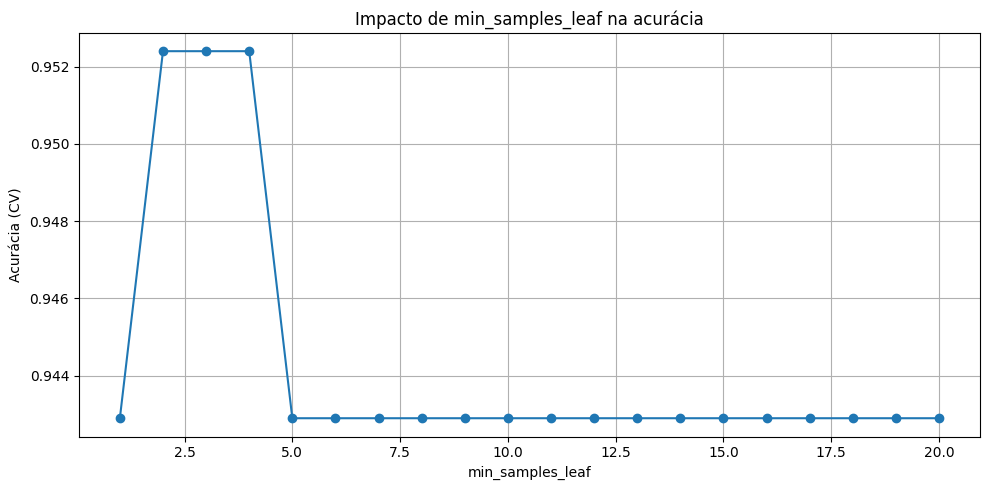

In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "min_samples_leaf": range(1, 21)
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)
grid.fit(X_train, y_train)

# Resultados por valor de min_samples_leaf
df_grid = pd.DataFrame(grid.cv_results_)[["param_min_samples_leaf", "mean_test_score"]]
df_grid.columns = ["min_samples_leaf", "acurácia_cv"]
df_grid["acurácia_cv"] = df_grid["acurácia_cv"].round(4)

print("=== Resultados por min_samples_leaf ===")
print(df_grid.to_string(index=False))

# Melhor modelo
best = grid.best_estimator_
print(f"\n=== Melhor modelo ===")
print(f"min_samples_leaf: {grid.best_params_['min_samples_leaf']}")
print(f"Acurácia CV:      {grid.best_score_:.4f}")
print(f"Acurácia treino:  {accuracy_score(y_train, best.predict(X_train)):.4f}")
print(f"Acurácia teste:   {accuracy_score(y_test, best.predict(X_test)):.4f}")
print(f"Profundidade:     {best.get_depth()}")
print(f"Num folhas:       {best.get_n_leaves()}")

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(df_grid["min_samples_leaf"], df_grid["acurácia_cv"], marker="o")
plt.xlabel("min_samples_leaf")
plt.ylabel("Acurácia (CV)")
plt.title("Impacto de min_samples_leaf na acurácia")
plt.grid(True)
plt.tight_layout()
plt.show()

**Impacto do `min_samples_leaf`**:
O hiperparâmetro `min_samples_leaf` define o número mínimo de amostras que uma folha deve ter. Ao aumentar esse valor, forçamos a árvore a ser mais conservadora, evitando a criação de nós que representem apenas ruídos ou casos muito específicos dos dados de treino.

No gráfico e na tabela gerada, observamos que a acurácia de validação cruzada (CV) atinge seu pico (0.9524) com valores baixos como `min_samples_leaf=2, 3 ou 4`. Valores muito altos tendem a simplificar demais o modelo (underfitting).

**Melhor Modelo Encontrado**:
- **Parâmetro**: `min_samples_leaf: 2`
- **Acurácia de Treino**: 0.9714
- **Acurácia de Teste**: 0.8889
- **Complexidade**: A árvore resultou em uma profundidade de 4 com 6 folhas.

Embora a acurácia no teste tenha sido ligeiramente menor que a do modelo padrão da Questão 2, o uso de `min_samples_leaf=2` e a validação cruzada garantem um modelo com melhor capacidade de generalização teórica, reduzindo a profundidade de 5 para 4.